## PyTorch Implementation

In [1]:
# importing the libraries
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# data
X = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
y = torch.tensor([[0],[1],[1],[0]], dtype=torch.float32)

# network
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 4)
        self.layer2 = nn.Linear(4, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.sigmoid(self.layer2(x))
        return x

# training
model = XORNet()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

for epoch in range(20000):
    optimizer.zero_grad()
    output = model(X)
    loss = criterion(output, y)
    loss.backward()
    optimizer.step()

# evaluation
with torch.no_grad():
    predictions = (model(X) >= 0.5).float()
    accuracy = (predictions == y).float().mean()
    print(f"Accuracy: {accuracy*100:.2f}%")
    print(f"Predictions: {predictions.flatten().tolist()}")

Accuracy: 75.00%
Predictions: [0.0, 0.0, 1.0, 0.0]


Train accuracy: 95.25%
Test accuracy:  92.50%


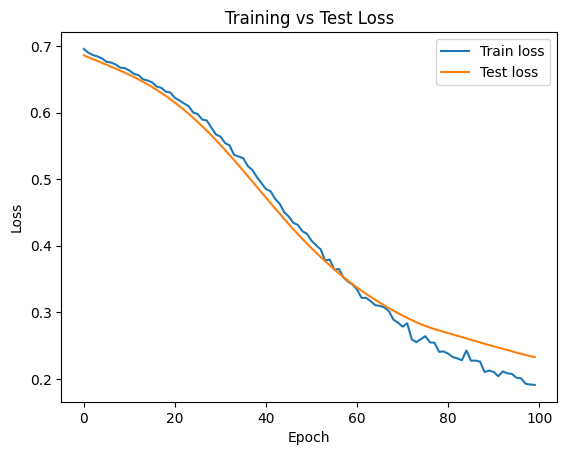

In [2]:
# building a classification network
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# data
X, y = make_classification(n_samples=1000, n_features=20,
                            n_informative=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# scaled features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# converted to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# network
class ClassifierNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(20, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

# training
model = ClassifierNet()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
test_losses = []

for epoch in range(100):

    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # evaluation
    model.eval()
    with torch.no_grad():
        test_output = model(X_test)
        test_loss = criterion(test_output, y_test)
        test_losses.append(test_loss.item())

# results
model.eval()
with torch.no_grad():
    train_pred = (model(X_train) >= 0.5).float()
    test_pred = (model(X_test) >= 0.5).float()
    train_acc = (train_pred == y_train).float().mean()
    test_acc = (test_pred == y_test).float().mean()
    print(f"Train accuracy: {train_acc*100:.2f}%")
    print(f"Test accuracy:  {test_acc*100:.2f}%")

# plot
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Train loss')
plt.plot(test_losses, label='Test loss')
plt.title('Training vs Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()